# Daily statistics from hourly ERA5 data

In [5]:
from earthkit import data as ekd
from earthkit import plots as ekp
from earthkit import transforms as ekt
from earthkit.meteo import thermo

## Load some data from the CDS

Download some [ERA5-land data](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-land)
from the [Climate Data Store](https://cds.climate.copernicus.eu).
This examples eight parameters over Europe for January 2020.

Please note that you require a CDS API key to access the CDS data.
Ideally they should be in your ~/.cdsapirc file, if they are not you will
be prompted for the credentials when executing the following cell.
For more details on setting up your CDS credentials please see the
[How to API page](https://cds.climate.copernicus.eu/how-to-api) in the CDS.

In [2]:

dataset = "reanalysis-era5-land"
request = {
    "variable": [
        "2m_dewpoint_temperature",
        "2m_temperature",
        "surface_net_solar_radiation",
        "surface_net_thermal_radiation",
        "10m_u_component_of_wind",
        "10m_v_component_of_wind",
        "surface_pressure",
        "total_precipitation"
    ],
    "year": "2020",
    "month": "01",
    "day": [
        "01", "02", "03",
        "04", "05", "06",
        "07", "08", "09",
        "10", "11", "12",
        "13", "14", "15",
        "16", "17", "18",
        "19", "20", "21",
        "22", "23", "24",
        "25", "26", "27",
        "28", "29", "30",
        "31"
    ],
    "time": [
        "00:00", "01:00", "02:00",
        "03:00", "04:00", "05:00",
        "06:00", "07:00", "08:00",
        "09:00", "10:00", "11:00",
        "12:00", "13:00", "14:00",
        "15:00", "16:00", "17:00",
        "18:00", "19:00", "20:00",
        "21:00", "22:00", "23:00"
    ],
    "area": [65, -10, 45, 5],  # North, West, South, East
}
era5_data_sl = ekd.from_source("cds", dataset, request)
era5_data_sl.describe()

2026-04-23 09:59:36,249 INFO [2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-land-timeseries?tab=overview)
2026-04-23 09:59:36,250 INFO Request ID is 0ef11b1b-c4c9-449b-97d3-97f388db1691
2026-04-23 09:59:36,406 INFO status has been updated to accepted
2026-04-23 09:59:50,036 INFO status has been updated to running
Recovering from connection error [HTTPSConnectionPool(host='cds.climate.copernicus.eu', port=443): Max retries exceeded with url: /api/retrieve/v1/jobs/0ef11b1b-c4c9-449b-97d3-97f388db1691?log=True&request=True (Caused by NameResolutionError("HTTPSConnection(host='cds.climate.copernicus.eu', port=443): Fa

5982f85308b96152d5660056802948c9.zip:   0%|          | 0.00/95.8M [00:00<?, ?B/s]

  0%|          | 0/1 [00:00<?, ?it/s]

path,/var/folders/l2/529q7bzs665bnrn7_wjx1nsr0000gn/T/earthkit-data-edwardcomyn-platt/cds-9bef0646c93b0d9c2bc86c51cebb1b83d2938ee668f72f789e0064f4b7d2e6c2.d/data.grib
size,135.9 MiB
types,"fieldlist, pandas, xarray, numpy, array"


The returned object is an `earthkit.data` object, it allows you to easily transform the object into the format
required for your workflow. The `describe` output above displays the basic information related to the data
we have downloaded. It is a `GRIB file` data object, the `types` field list the object types that it is
compatible with.

The code cell below opens the data as an `xarray.Dataset` using the earthkit engine.
The `xarray` representation allows you to explore the contents of the grib file.
Note that xarray can only represent hypercubes, but there are tools in earthkit which help you open complex
grib files as xarray. For example, in this case we set `time_dim_mode="valid_time"` which ensures that
the accumualted variables (e.g. precipitation and radiation) have the same time dimension
values as the instantaneous variables (e.g. temperature, pressure and wind).

In [3]:
era5_ds = era5_data_sl.to_xarray(time_dim_mode="valid_time")
era5_ds

<xarray.Dataset> Size: 1GB
Dimensions:     (valid_time: 744, latitude: 201, longitude: 151)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 6kB 2020-01-01 ... 2020-01-31T23:...
  * latitude    (latitude) float64 2kB 65.0 64.9 64.8 64.7 ... 45.2 45.1 45.0
  * longitude   (longitude) float64 1kB -10.0 -9.9 -9.8 -9.7 ... 4.7 4.8 4.9 5.0
Data variables:
    10u         (valid_time, latitude, longitude) float64 181MB ...
    10v         (valid_time, latitude, longitude) float64 181MB ...
    2d          (valid_time, latitude, longitude) float64 181MB ...
    2t          (valid_time, latitude, longitude) float64 181MB ...
    sp          (valid_time, latitude, longitude) float64 181MB ...
    ssr         (valid_time, latitude, longitude) float64 181MB ...
    str         (valid_time, latitude, longitude) float64 181MB ...
    tp          (valid_time, latitude, longitude) float64 181MB ...
Attributes:
    Conventions:  CF-1.8
    institution:  ECMWF

## Derive some additional fields

### Humidity fields with `earthkit.meteo`

We can use `earthkit.meteo` to derive some additional fields which are not available as surface variables in the ERA5 archive. The examples below calculates the Specific and Relative humidities using the surface variables we downloaded.

**Specific humidity** with dew point temperature and surface pressure

In [6]:
sh_da = thermo.specific_humidity_from_dewpoint(
    era5_ds["2d"], era5_ds["sp"]
)
# Update some metadata fields:
sh_da.attrs["standard_name"] = "specific_humidity"
sh_da.attrs["long_name"] = "Specific humidity near the surface"
sh_da = sh_da.rename("q2m")
# Add to our existing dataset:
era5_ds["2q"] = sh_da

**Relative humidity** with air temperature and dew point temperature

In [7]:
rh_da = thermo.relative_humidity_from_dewpoint(
    era5_ds["2t"], era5_ds["2d"]
)
# Update some metadata fields:
rh_da.attrs["standard_name"] = "relative_humidity"
rh_da.attrs["long_name"] = "Relative humidity near the surface"
rh_da = rh_da.rename("r2m")
# Add to our existing dataset:
era5_ds["2r"] = rh_da
era5_ds

<xarray.Dataset> Size: 2GB
Dimensions:     (valid_time: 744, latitude: 201, longitude: 151)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 6kB 2020-01-01 ... 2020-01-31T23:...
  * latitude    (latitude) float64 2kB 65.0 64.9 64.8 64.7 ... 45.2 45.1 45.0
  * longitude   (longitude) float64 1kB -10.0 -9.9 -9.8 -9.7 ... 4.7 4.8 4.9 5.0
Data variables:
    10u         (valid_time, latitude, longitude) float64 181MB ...
    10v         (valid_time, latitude, longitude) float64 181MB ...
    2d          (valid_time, latitude, longitude) float64 181MB nan ... 280.6
    2t          (valid_time, latitude, longitude) float64 181MB nan ... 280.7
    sp          (valid_time, latitude, longitude) float64 181MB nan ... 9.798...
    ssr         (valid_time, latitude, longitude) float64 181MB ...
    str         (valid_time, latitude, longitude) float64 181MB ...
    tp          (valid_time, latitude, longitude) float64 181MB ...
    2q          (valid_time, latitude, longitude) float64 181MB nan ... 0.006585
    2r          (valid_time, latitude, longitude) float64 181MB nan ... 99.57
Attributes:
    Conventions:  CF-1.8
    institution:  ECMWF

### Convert accumulated radiation to a rate value with `earthkit-transforms`

The accumulated variables (e.g. radiation and temperature) in ERA5-Land archived as the accumulation
since the start of day.
This is useful for archiving purposes, however many applications require instantaneous rate variables.
Earthkit-transforms provides an accumulation_to_rate function which simplifies this calculation,
which is particularly tricky for "start of day" accumulation.

For a more detailed description, with examples please to the
[tutorial in the earthkit-transforms documentation](https://earthkit-transforms.readthedocs.io/en/latest/tutorials/temporal/05-accumulation-to-rate-examples.html)

In [ ]:
tp_rate = ekt.temporal.accumulation_to_rate(era5_ds["tp"], accumulation_type="start_of_day")
ssr_rate = ekt.temporal.accumulation_to_rate(era5_ds["ssr"], accumulation_type="start_of_day")
str_rate = ekt.temporal.accumulation_to_rate(era5_ds["str"], accumulation_type="start_of_day")
# Add to our existing dataset:
era5_ds["tp_rate"] = tp_rate
era5_ds["ssr_rate"] = ssr_rate
era5_ds["str_rate"] = str_rate
era5_ds

Please be aware that using accumulation_type='start_of_day' with a 'valid_time' representation assumes that the data is contiguous with steps that can be identified as midnight in order to reset accumulation.
Please be aware that using accumulation_type='start_of_day' with a 'valid_time' representation assumes that the data is contiguous with steps that can be identified as midnight in order to reset accumulation.
Please be aware that using accumulation_type='start_of_day' with a 'valid_time' representation assumes that the data is contiguous with steps that can be identified as midnight in order to reset accumulation.


<xarray.Dataset> Size: 2GB
Dimensions:     (valid_time: 744, latitude: 201, longitude: 151)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 6kB 2020-01-01 ... 2020-01-31T23:...
  * latitude    (latitude) float64 2kB 65.0 64.9 64.8 64.7 ... 45.2 45.1 45.0
  * longitude   (longitude) float64 1kB -10.0 -9.9 -9.8 -9.7 ... 4.7 4.8 4.9 5.0
Data variables: (12/13)
    10u         (valid_time, latitude, longitude) float64 181MB ...
    10v         (valid_time, latitude, longitude) float64 181MB ...
    2d          (valid_time, latitude, longitude) float64 181MB nan ... 280.6
    2t          (valid_time, latitude, longitude) float64 181MB nan ... 280.7
    sp          (valid_time, latitude, longitude) float64 181MB nan ... 9.798...
    ssr         (valid_time, latitude, longitude) float64 181MB nan ... 4.44e+06
    ...          ...
    tp          (valid_time, latitude, longitude) float64 181MB nan ... 0.001529
    2q          (valid_time, latitude, longitude) float64 181MB nan ... 0.006585
    2r          (valid_time, latitude, longitude) float64 181MB nan ... 99.57
    tp_rate     (valid_time, latitude, longitude) float64 181MB nan nan ... 0.0
    ssr_rate    (valid_time, latitude, longitude) float64 181MB nan nan ... 0.0
    str_rate    (valid_time, latitude, longitude) float64 181MB nan ... -40.63
Attributes:
    Conventions:  CF-1.8
    institution:  ECMWF

## Calculate the monthly mean of the daily maximum

We can use `earthkit.transforms` to calculate monthly and daily statistics of the variables in the dataset.

We will calculate the monthly mean of the daily maximum of all the variables.
As we have a single month of data, this will reduce to a single time step,
very convenient for our subsequent plotting.
Note that this calculation may not be useful for all the variables in our dataset,
we just demonstrate the simplicity of performing the calculations in batch.

In [9]:
era5_ds_daily_max = ekt.temporal.daily_max(era5_ds)
era5_ds_monthly_mean_daily_max = ekt.temporal.monthly_mean(era5_ds_daily_max)
era5_ds_monthly_mean_daily_max

<xarray.Dataset> Size: 3MB
Dimensions:     (valid_time: 1, latitude: 201, longitude: 151)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 8B 2020-01-01
  * latitude    (latitude) float64 2kB 65.0 64.9 64.8 64.7 ... 45.2 45.1 45.0
  * longitude   (longitude) float64 1kB -10.0 -9.9 -9.8 -9.7 ... 4.7 4.8 4.9 5.0
Data variables: (12/13)
    10u         (valid_time, latitude, longitude) float64 243kB nan ... 0.4682
    10v         (valid_time, latitude, longitude) float64 243kB nan ... 1.321
    2d          (valid_time, latitude, longitude) float64 243kB nan ... 277.8
    2t          (valid_time, latitude, longitude) float64 243kB nan ... 282.1
    sp          (valid_time, latitude, longitude) float64 243kB nan ... 9.895...
    ssr         (valid_time, latitude, longitude) float64 243kB nan ... 5.321...
    ...          ...
    tp          (valid_time, latitude, longitude) float64 243kB nan ... 0.001792
    2q          (valid_time, latitude, longitude) float64 243kB nan ... 0.005468
    2r          (valid_time, latitude, longitude) float64 243kB nan ... 94.69
    tp_rate     (valid_time, latitude, longitude) float64 243kB nan ... 5.306...
    ssr_rate    (valid_time, latitude, longitude) float64 243kB nan ... 244.0
    str_rate    (valid_time, latitude, longitude) float64 243kB nan ... -21.1
Attributes:
    Conventions:  CF-1.8
    institution:  ECMWF

## Plot the output

Something about `earthkit-plots`

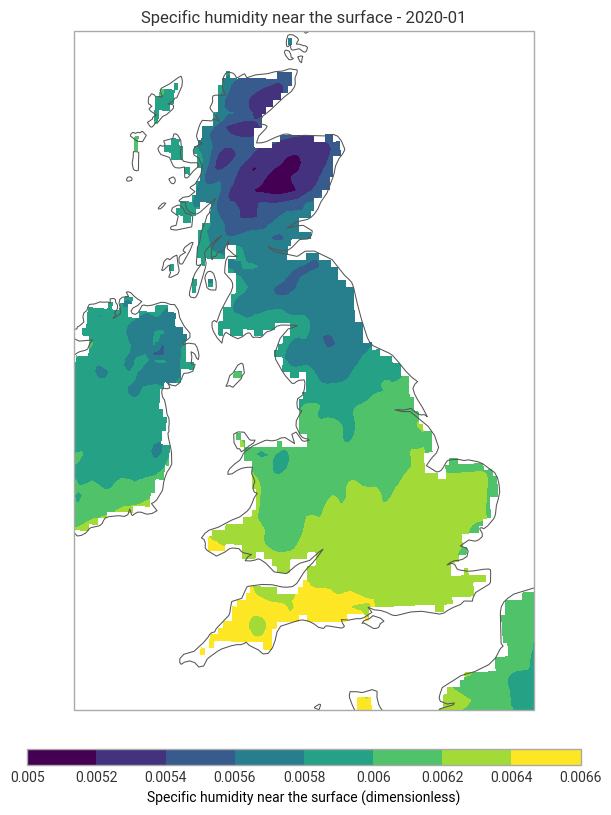

In [23]:
ekp.quickplot(
    era5_ds_monthly_mean_daily_max[["2q"]], domain="UK",
    title="{long_name} - {valid_time:%Y-%m}",
)